In [8]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.2 MB 2.0 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.2 MB 2.4 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 2.3 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.2 MB 2.2 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.2 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.2 MB 2.5 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 2.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 2.6 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 2.7 MB/s eta 0:00:02
   ------------------------------ --------- 6.3/8.2 MB 2.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 2.7 MB/s eta 0:00:01
   ----------------

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
from pathlib import Path

current_dir = Path.cwd()

ROOT_DIR = next(
    path
    for path in [current_dir, *current_dir.parents]
    if (path / 'crawl_data').exists()
)

DATA_DIR = ROOT_DIR / 'crawl_data'

print('프로젝트 루트:', ROOT_DIR)
print('데이터 폴더:', DATA_DIR)

프로젝트 루트: c:\Users\model\Documents\10th-toy-team5
데이터 폴더: c:\Users\model\Documents\10th-toy-team5\crawl_data


In [5]:
from pathlib import Path

DATA_DIR = Path(
    r'C:\Users\model\Documents\10th-toy-team5\crawl_data'
)

print('폴더 존재:', DATA_DIR.exists())
print(
    '파일 존재:',
    (DATA_DIR / 'Final_datasets.csv').exists()
)

폴더 존재: True
파일 존재: True


In [6]:
feature_df = pd.read_csv(
    DATA_DIR / 'Final_datasets.csv'
)

target_df = pd.read_csv(
    DATA_DIR / 'X_model_time_controlled.csv',
    usecols=[
        'activity_id',
        'daily_views_log1p',
        'scrap_rate (%)'
    ]
)

print('피처 데이터:', feature_df.shape)
print('타깃 데이터:', target_df.shape)

피처 데이터: (7264, 101)
타깃 데이터: (7264, 3)


In [7]:
df = feature_df.merge(
    target_df,
    on='activity_id',
    how='left',
    validate='one_to_one'
)

print('병합 결과:', df.shape)

print(
    df[
        ['daily_views_log1p', 'scrap_rate (%)']
    ].isna().sum()
)

병합 결과: (7264, 103)
daily_views_log1p    0
scrap_rate (%)       0
dtype: int64


In [8]:
text_svd_cols = [
    col for col in df.columns
    if col.startswith('text_svd_')
]

exclude_cols = [
    'activity_id',
    'daily_views_log1p',
    'scrap_rate (%)',
    'org_target_enc_A',
    'org_target_enc_B'
] + text_svd_cols

X_cluster = df.drop(
    columns=exclude_cols
).copy()

# 나중에 군집별 성과를 비교할 데이터
cluster_result = df[
    [
        'activity_id',
        'daily_views_log1p',
        'scrap_rate (%)'
    ]
].copy()

print('클러스터링 입력:', X_cluster.shape)
print('결과 분석 데이터:', cluster_result.shape)

클러스터링 입력: (7264, 78)
결과 분석 데이터: (7264, 3)


In [9]:
# 결측치 확인
missing = X_cluster.isna().sum()

print(
    missing[missing > 0]
)

activity_period_months    160
dtype: int64


In [10]:
median_months = X_cluster[
    'activity_period_months'
].median()

X_cluster[
    'activity_period_months'
] = X_cluster[
    'activity_period_months'
].fillna(median_months)

# True/False를 1/0으로 변환
bool_cols = X_cluster.select_dtypes(
    include='bool'
).columns

X_cluster[bool_cols] = (
    X_cluster[bool_cols].astype(int)
)

print('사용한 중앙값:', median_months)
print('남은 결측치:', X_cluster.isna().sum().sum())
print('최종 데이터 크기:', X_cluster.shape)

사용한 중앙값: 4.0
남은 결측치: 0
최종 데이터 크기: (7264, 78)


In [11]:
continuous_cols = [
    'recruit_period_days',
    'recruit_end_dow',
    'recruit_end_month',
    'activity_period_months',
    'title_length',
    'preferred_count',
    'benefit_count'
]

X_scaled = X_cluster.copy()

scaler = StandardScaler()

X_scaled[continuous_cols] = scaler.fit_transform(
    X_cluster[continuous_cols]
)

print('스케일링 결과:', X_scaled.shape)

display(
    X_scaled[continuous_cols]
    .agg(['mean', 'std'])
    .round(3)
)

스케일링 결과: (7264, 78)


,recruit_period_days,recruit_end_dow,recruit_end_month,activity_period_months,title_length,preferred_count,benefit_count
mean,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [12]:
k_results = []
kmeans_models = {}

for k in range(2, 9):
    
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        max_iter=300,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=3000,
        random_state=42
    )
    
    cluster_sizes = pd.Series(labels).value_counts()
    
    k_results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette_score': silhouette,
        'smallest_cluster': cluster_sizes.min()
    })
    
    kmeans_models[k] = kmeans

k_score_df = pd.DataFrame(k_results)

display(
    k_score_df.round(4)
)

,k,inertia,silhouette_score,smallest_cluster
0,2,79746.9078,0.1092,2117
1,3,74501.4014,0.0939,1932
2,4,70511.4472,0.0942,503
3,5,67260.2751,0.0902,128
4,6,64349.0654,0.0933,122
5,7,62163.9918,0.0856,126
6,8,60499.9564,0.0865,125


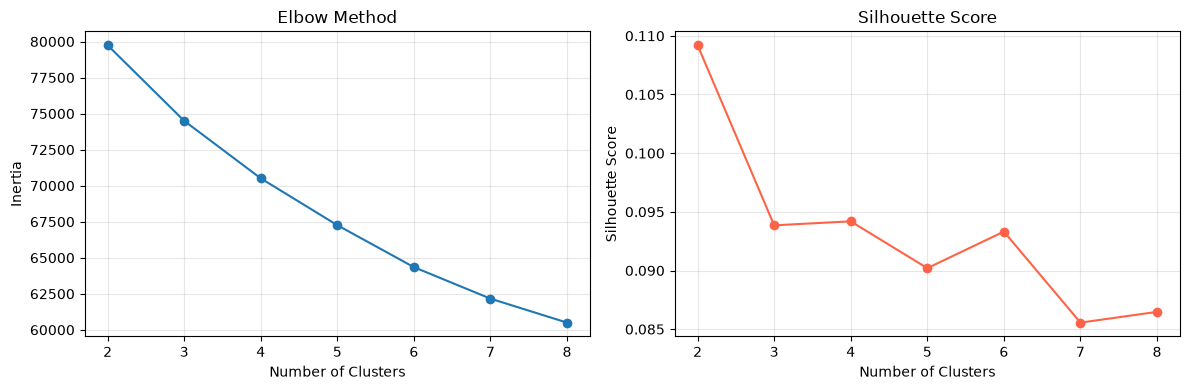

In [13]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4)
)

axes[0].plot(
    k_score_df['k'],
    k_score_df['inertia'],
    marker='o'
)

axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(
    k_score_df['k'],
    k_score_df['silhouette_score'],
    marker='o',
    color='tomato'
)

axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
best_k = 2

final_kmeans = kmeans_models[best_k]

cluster_labels = final_kmeans.labels_

analysis_df = df.copy()
analysis_df['cluster'] = cluster_labels

cluster_counts = (
    analysis_df['cluster']
    .value_counts()
    .sort_index()
    .rename('count')
    .to_frame()
)

cluster_counts['ratio (%)'] = (
    cluster_counts['count']
    / len(analysis_df)
    * 100
).round(2)

display(cluster_counts)

,count,ratio (%)
cluster,,
0,2117,29.14
1,5147,70.86


In [15]:
# 로그 조회수를 원래 일평균 조회수 단위로 복원
analysis_df['daily_views'] = np.expm1(
    analysis_df['daily_views_log1p']
)

cluster_performance = (
    analysis_df
    .groupby('cluster')
    .agg(
        count=('activity_id', 'count'),
        daily_views_mean=('daily_views', 'mean'),
        daily_views_median=('daily_views', 'median'),
        scrap_rate_mean=('scrap_rate (%)', 'mean'),
        scrap_rate_median=('scrap_rate (%)', 'median')
    )
    .round(2)
)

display(cluster_performance)

,count,daily_views_mean,daily_views_median,scrap_rate_mean,scrap_rate_median
cluster,,,,,
0,2117,79.94,34.50,2.07,1.85
1,5147,130.68,53.33,2.76,2.68


In [16]:
profile_df = X_cluster.copy()
profile_df['cluster'] = cluster_labels

profile_cols = [
    'recruit_period_days',
    'activity_period_months',
    'title_length',
    'preferred_count',
    'benefit_count'
]

continuous_profile = (
    profile_df
    .groupby('cluster')[profile_cols]
    .mean()
    .T
)

continuous_profile.columns = [
    'cluster_0',
    'cluster_1'
]

continuous_profile['difference_1_minus_0'] = (
    continuous_profile['cluster_1']
    - continuous_profile['cluster_0']
)

display(
    continuous_profile.round(2)
)

,cluster_0,cluster_1,difference_1_minus_0
recruit_period_days,25.56,26.56,1.00
activity_period_months,4.17,5.20,1.02
title_length,29.57,32.85,3.28
preferred_count,1.00,2.35,1.35
benefit_count,1.00,2.00,1.00


In [17]:
# 값이 0과 1로만 구성된 피처 탐색
binary_cols = [
    col for col in X_cluster.columns
    if set(
        X_cluster[col].dropna().unique()
    ).issubset({0, 1})
]

binary_profile = (
    profile_df
    .groupby('cluster')[binary_cols]
    .mean()
    .T
)

binary_profile.columns = [
    'cluster_0_ratio',
    'cluster_1_ratio'
]

binary_profile['difference_pp'] = (
    binary_profile['cluster_1_ratio']
    - binary_profile['cluster_0_ratio']
) * 100

# 군집 1에서 많이 나타나는 피처
cluster_1_features = (
    binary_profile
    .sort_values('difference_pp', ascending=False)
    .head(10)
    .mul({
        'cluster_0_ratio': 100,
        'cluster_1_ratio': 100,
        'difference_pp': 1
    })
    .round(2)
)

# 군집 0에서 많이 나타나는 피처
cluster_0_features = (
    binary_profile
    .sort_values('difference_pp')
    .head(10)
    .mul({
        'cluster_0_ratio': 100,
        'cluster_1_ratio': 100,
        'difference_pp': 1
    })
    .round(2)
)

print('군집 1에서 상대적으로 많이 나타나는 피처')
display(cluster_1_features)

print('군집 0에서 상대적으로 많이 나타나는 피처')
display(cluster_0_features)

군집 1에서 상대적으로 많이 나타나는 피처


,cluster_0_ratio,cluster_1_ratio,difference_pp
extra_benefit_exists,18.85,40.18,21.33
target_대학생,12.38,30.64,18.26
activity_field_멘토링,7.18,18.75,11.57
company_type_비영리단체/협회/재단,27.73,37.81,10.08
activity_field_서포터즈,52.05,60.91,8.85
interest_field_경영/컨설팅/마케팅,6.28,15.10,8.81
title_has_number,71.80,80.24,8.44
activity_field_마케터,6.85,14.80,7.96
interest_field_교육,11.90,18.65,6.75
activity_region_서울,16.53,22.67,6.14


군집 0에서 상대적으로 많이 나타나는 피처


,cluster_0_ratio,cluster_1_ratio,difference_pp
recruit_season_2학기중,26.59,15.89,-10.70
company_type_중소기업,26.83,18.88,-7.95
company_type_기타,11.24,5.42,-5.82
activity_region_전국/제한없음,57.58,52.81,-4.77
interest_field_요리/식품,5.15,2.23,-2.91
target_직장인/일반인,2.98,0.99,-1.99
activity_region_경기,8.22,6.49,-1.73
activity_region_경상,2.83,1.71,-1.12
activity_field_강연,10.20,9.15,-1.05
interest_field_정치/사회/법률,5.48,4.43,-1.05


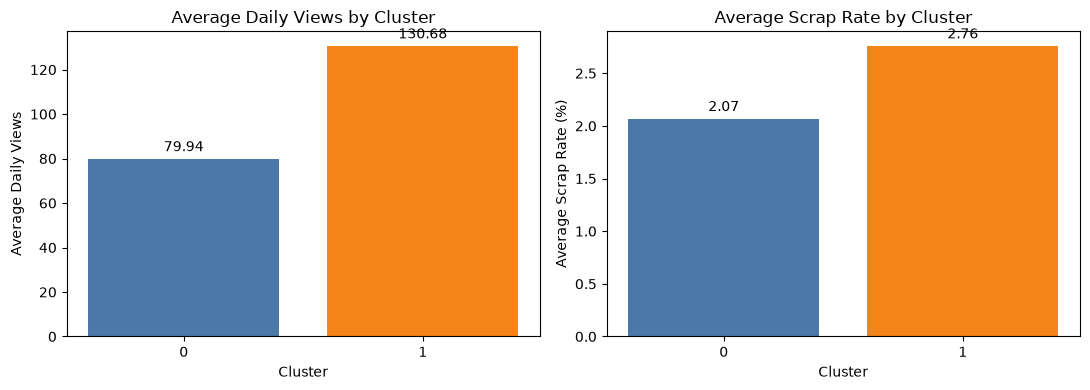

In [18]:
colors = ['#4C78A8', '#F58518']

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4)
)

# 평균 일일 조회수
axes[0].bar(
    cluster_performance.index.astype(str),
    cluster_performance['daily_views_mean'],
    color=colors
)

axes[0].set_title('Average Daily Views by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Average Daily Views')

# 평균 전환율
axes[1].bar(
    cluster_performance.index.astype(str),
    cluster_performance['scrap_rate_mean'],
    color=colors
)

axes[1].set_title('Average Scrap Rate by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Average Scrap Rate (%)')

for ax in axes:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f',
            padding=3
        )

plt.tight_layout()
plt.show()

In [19]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'cluster': cluster_labels
})

# K-means 중심점도 같은 PCA 공간으로 변환
centers_pca = pca.transform(
    final_kmeans.cluster_centers_
)

explained_ratio = (
    pca.explained_variance_ratio_
    * 100
)

print(
    'PCA 설명 분산:',
    explained_ratio.round(2)
)

print(
    '누적 설명 분산:',
    explained_ratio.sum().round(2),
    '%'
)

PCA 설명 분산: [13.45 10.65]
누적 설명 분산: 24.11 %


c:\Users\model\Documents\10th-toy-team5\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


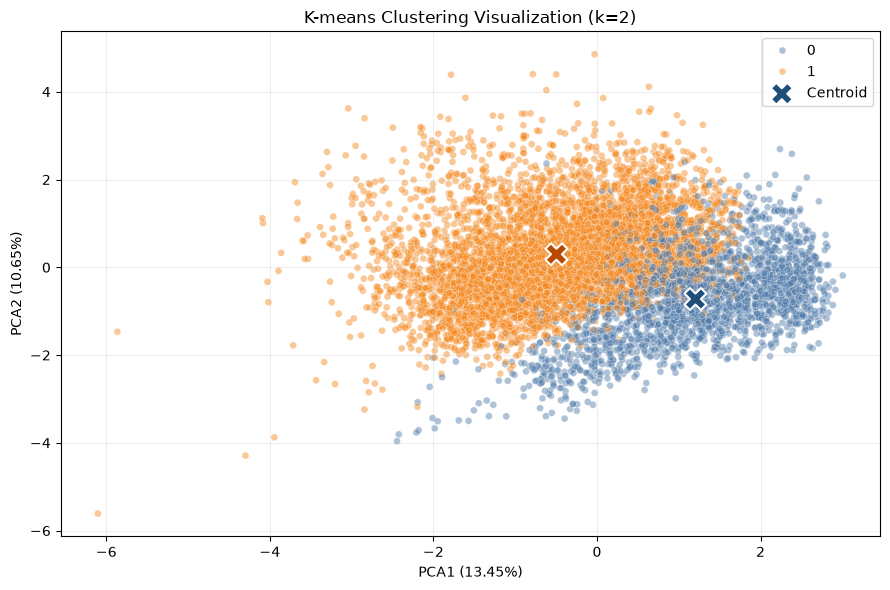

저장 위치: c:\Users\model\Documents\10th-toy-team5\modeling\clustering_analysis\kmeans_pca_clusters.png


In [22]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette={
        0: '#4C78A8',
        1: '#F58518'
    },
    alpha=0.45,
    s=25
)

# 군집 중심점
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker='X',
    s=250,
    c=['#1F4E79', '#B84A00'],
    edgecolor='white',
    linewidth=1.5,
    label='Centroid'
)

plt.xlabel(
    f'PCA1 ({explained_ratio[0]:.2f}%)'
)

plt.ylabel(
    f'PCA2 ({explained_ratio[1]:.2f}%)'
)

plt.title(
    'K-means Clustering Visualization (k=2)'
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

output_path = (
    Path.cwd()
    / 'kmeans_pca_clusters.png'
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('저장 위치:', output_path)

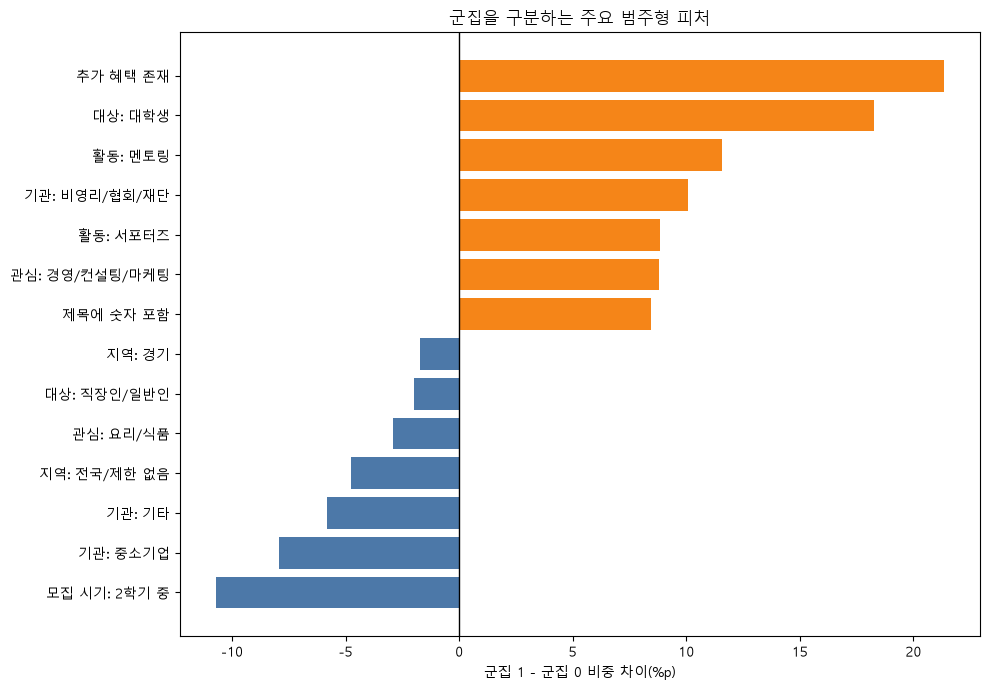

저장 위치: c:\Users\model\Documents\10th-toy-team5\modeling\clustering_analysis\cluster_feature_difference.png


In [23]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

top_cluster_1 = binary_profile.nlargest(
    7,
    'difference_pp'
)

top_cluster_0 = binary_profile.nsmallest(
    7,
    'difference_pp'
)

feature_plot_df = pd.concat([
    top_cluster_0,
    top_cluster_1
]).sort_values('difference_pp')

feature_names = {
    'extra_benefit_exists': '추가 혜택 존재',
    'target_대학생': '대상: 대학생',
    'activity_field_멘토링': '활동: 멘토링',
    'company_type_비영리단체/협회/재단': '기관: 비영리/협회/재단',
    'activity_field_서포터즈': '활동: 서포터즈',
    'interest_field_경영/컨설팅/마케팅': '관심: 경영/컨설팅/마케팅',
    'title_has_number': '제목에 숫자 포함',
    'recruit_season_2학기중': '모집 시기: 2학기 중',
    'company_type_중소기업': '기관: 중소기업',
    'company_type_기타': '기관: 기타',
    'activity_region_전국/제한없음': '지역: 전국/제한 없음',
    'interest_field_요리/식품': '관심: 요리/식품',
    'target_직장인/일반인': '대상: 직장인/일반인',
    'activity_region_경기': '지역: 경기'
}

plot_labels = [
    feature_names.get(name, name)
    for name in feature_plot_df.index
]

bar_colors = [
    '#4C78A8' if value < 0
    else '#F58518'
    for value in feature_plot_df['difference_pp']
]

plt.figure(figsize=(10, 7))

plt.barh(
    plot_labels,
    feature_plot_df['difference_pp'],
    color=bar_colors
)

plt.axvline(
    0,
    color='black',
    linewidth=1
)

plt.xlabel(
    '군집 1 - 군집 0 비중 차이(%p)'
)

plt.title(
    '군집을 구분하는 주요 범주형 피처'
)

plt.tight_layout()

feature_plot_path = (
    Path.cwd()
    / 'cluster_feature_difference.png'
)

plt.savefig(
    feature_plot_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('저장 위치:', feature_plot_path)

In [24]:
cluster_name_map = {
    0: '일반·범용 모집형',
    1: '혜택·대학생 특화형'
}

analysis_df['cluster_name'] = (
    analysis_df['cluster']
    .map(cluster_name_map)
)

# 공고별 군집 결과
cluster_assignment = analysis_df[
    [
        'activity_id',
        'cluster',
        'cluster_name',
        'daily_views_log1p',
        'daily_views',
        'scrap_rate (%)'
    ]
]

cluster_assignment.to_csv(
    Path.cwd() / 'kmeans_cluster_assignment.csv',
    index=False,
    encoding='utf-8-sig'
)

# 군집별 성과 요약
cluster_summary = (
    cluster_performance
    .reset_index()
)

cluster_summary['cluster_name'] = (
    cluster_summary['cluster']
    .map(cluster_name_map)
)

cluster_summary.to_csv(
    Path.cwd() / 'kmeans_cluster_summary.csv',
    index=False,
    encoding='utf-8-sig'
)

# 범주형 피처 비교 결과
binary_profile.to_csv(
    Path.cwd() / 'cluster_feature_profile.csv',
    encoding='utf-8-sig'
)

print('결과 저장 완료')

결과 저장 완료
